In [1]:
# %% [0] install
%pip install "paddleocr==2.10.0" paddlepaddle matplotlib
%pip install -q easyocr opencv-python-headless pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.7/193.7 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 95.1 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━

In [2]:
# %% [A] traQ fetch (messages + images) + save images
import os, re, io
import requests
from PIL import Image
import getpass

messageIds = [
    "019b2a64-eebc-7815-84c5-e384fabc495c",
    "019a48ff-b175-783c-93fc-b4ec6731dde5",
    "019bb6b8-5c57-7d1f-8b93-297c8e6c7827",
    "019bb5c0-5409-7b3b-ba9b-07449030364a",
    "019bd043-d86c-79b8-9cf1-11351a482267",
    "0197c4ef-8be2-792e-922b-c498b6948775",
    "01963951-0f55-75b5-a53b-07f467ad9051",
    "0195be37-dea6-7902-8d04-e46185873108",
    "019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa",
    "019bde55-b166-7d7b-b290-2f049f72fe08",
    "019bbd0d-5e27-77b2-8494-42499697c033",
    "019bde84-1609-7dc5-b8fc-f2c77bcdb005",
    "019bdeb4-6ec8-7e0e-b773-3bec85c35584",
    "019bb65e-9263-7c89-b123-95389f4414cd",
    "019b8cea-695d-7047-aafb-793c58d25eff",
]

r_session = getpass.getpass("r_session を入力してください（表示されません）: ").strip()
if not r_session:
    raise RuntimeError("r_session が空です")

BASE_URL = "https://q.trap.jp/api/v3"
_FILE_URL_RE = re.compile(r"https?://q\.trap\.jp/files/([0-9a-fA-F-]+)")

def _get_session() -> requests.Session:
    s = requests.Session()
    s.cookies.set("r_session", r_session)
    return s

def get_messages_and_images(message_ids):
    messages, images = [], []
    with _get_session() as session:
        for mid in message_ids:
            resp = session.get(f"{BASE_URL}/messages/{mid}")
            resp.raise_for_status()
            content = resp.json()["content"]

            file_ids = _FILE_URL_RE.findall(content)
            imgs = []
            for fid in file_ids:
                r = session.get(f"{BASE_URL}/files/{fid}")
                r.raise_for_status()
                try:
                    imgs.append(Image.open(io.BytesIO(r.content)).convert("RGB"))
                except Exception as e:
                    print(f"[skip] not an image fileId={fid}: {e}")

            text = _FILE_URL_RE.sub("", content).strip()
            messages.append(text)
            images.append(imgs)

    return messages, images

messages, images = get_messages_and_images(messageIds)
print("messages:", len(messages))
print("msgs with images:", sum(1 for x in images if len(x) > 0))

SAVE_DIR = "/content/traq_images"
os.makedirs(SAVE_DIR, exist_ok=True)

records = []
for mid, msg_text, imgs in zip(messageIds, messages, images):
    for j, im in enumerate(imgs):
        path = os.path.join(SAVE_DIR, f"{mid}_{j}.png")
        im.save(path)
        records.append({
            "messageId": mid,
            "image_index": j,
            "message_text": msg_text,
            "image_path": path,
        })

print("saved images:", len(records))
print("example:", records[0] if records else None)

messages: 15
msgs with images: 15
saved images: 20
example: {'messageId': '019b2a64-eebc-7815-84c5-e384fabc495c', 'image_index': 0, 'message_text': ':tada: 味処まるたかエグい\nhttps://icttoracon.net/archives/10329', 'image_path': '/content/traq_images/019b2a64-eebc-7815-84c5-e384fabc495c_0.png'}


In [3]:
# %% [B] OCR init (Easy vs Paddle)
import time, json, html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import easyocr
from paddleocr import PaddleOCR
from IPython.display import display, HTML

# 言語
LANG_MODE = "ja"   # "en" or "ja"
EASYOCR_LANGS = ["en"] if LANG_MODE == "en" else ["ja", "en"]
PADDLE_LANG  = "en" if LANG_MODE == "en" else "japan"

# EasyOCR
easy_reader = easyocr.Reader(EASYOCR_LANGS, gpu=False, download_enabled=True)

# Paddleの拾いすぎ抑制（ここを調整）
PADDLE_DET_DB_BOX_THRESH = 0.75  # 0.7〜0.85くらいで調整（上げるほど拾わない）
PADDLE_DROP_SCORE        = 0.75  # 0.7〜0.9くらいで調整（上げるほど低信頼を捨てる）

def init_paddle():
    # v3っぽい引数（TypeErrorならv2へ）
    try:
        return PaddleOCR(
            lang=PADDLE_LANG,
            use_doc_orientation_classify=False,
            use_doc_unwarping=False,
            use_textline_orientation=True,
            det_db_box_thresh=PADDLE_DET_DB_BOX_THRESH,
            drop_score=PADDLE_DROP_SCORE,
        )
    except TypeError:
        return PaddleOCR(
            lang=PADDLE_LANG,
            use_angle_cls=True,
            det_db_box_thresh=PADDLE_DET_DB_BOX_THRESH,
            drop_score=PADDLE_DROP_SCORE,
        )

paddle_ocr = init_paddle()
print("OCR engines initialized: EasyOCR + PaddleOCR")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Completedownload https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/Multilingual_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/ml/Multilingual_PP-OCRv3_det_infer/Multilingual_PP-OCRv3_det_infer.tar


100%|██████████| 3762/3762 [00:19<00:00, 192.56it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/multilingual/japan_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/japan/japan_PP-OCRv4_rec_infer/japan_PP-OCRv4_rec_infer.tar


100%|██████████| 9740/9740 [00:19<00:00, 506.94it/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:18<00:00, 115.00it/s]

[2026/03/05 12:43:19] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/ml/Multilingual_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.75, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/japan/japan_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_

OCR engines initialized: EasyOCR + PaddleOCR


[2026/03/05 12:43:35] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:43:35] ppocr DEBUG: dt_boxes num : 52, elapsed : 0.3184950351715088
[2026/03/05 12:43:38] ppocr DEBUG: rec_res num  : 52, elapsed : 2.7994320392608643
[2026/03/05 12:43:52] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:43:52] ppocr DEBUG: dt_boxes num : 52, elapsed : 0.2367246150970459
[2026/03/05 12:43:56] ppocr DEBUG: rec_res num  : 52, elapsed : 3.2140679359436035


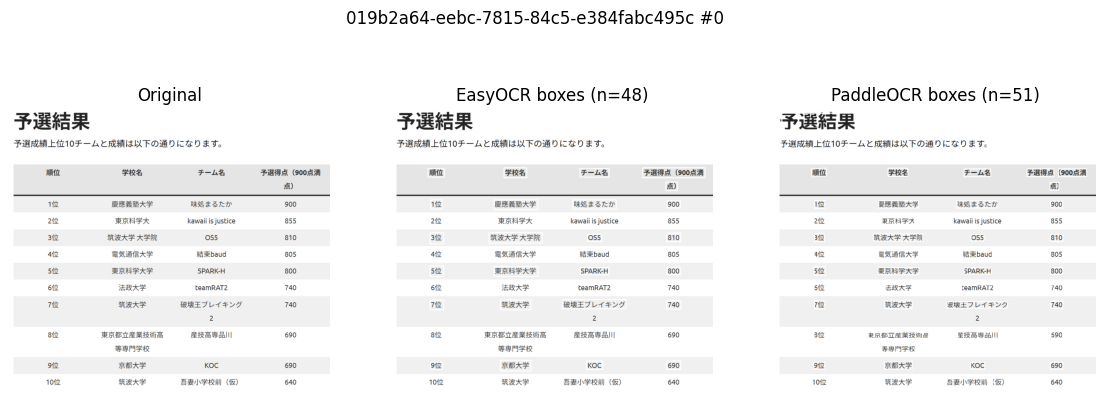

[2026/03/05 12:44:29] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:44:29] ppocr DEBUG: dt_boxes num : 41, elapsed : 0.28626394271850586
[2026/03/05 12:44:31] ppocr DEBUG: rec_res num  : 41, elapsed : 1.8993449211120605


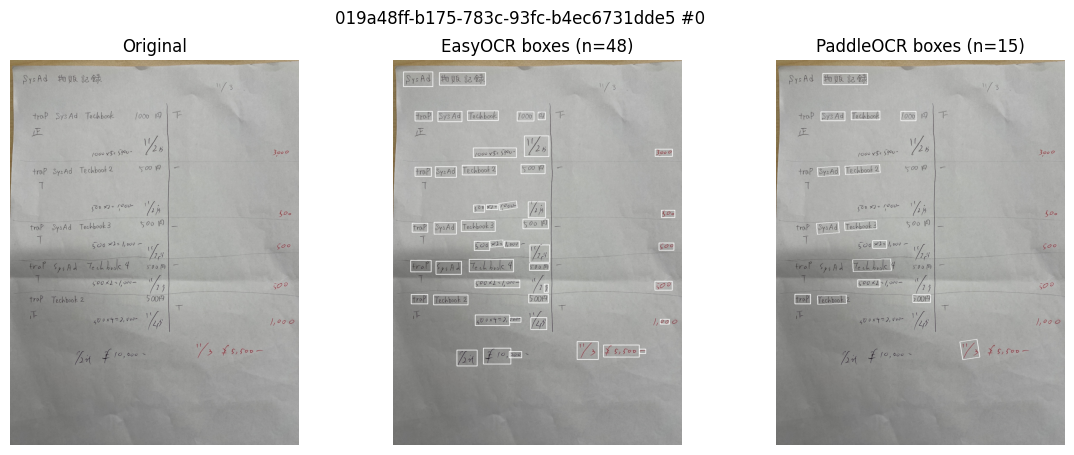

[2026/03/05 12:45:29] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:45:29] ppocr DEBUG: dt_boxes num : 8, elapsed : 0.27702879905700684
[2026/03/05 12:45:30] ppocr DEBUG: rec_res num  : 8, elapsed : 0.6925630569458008


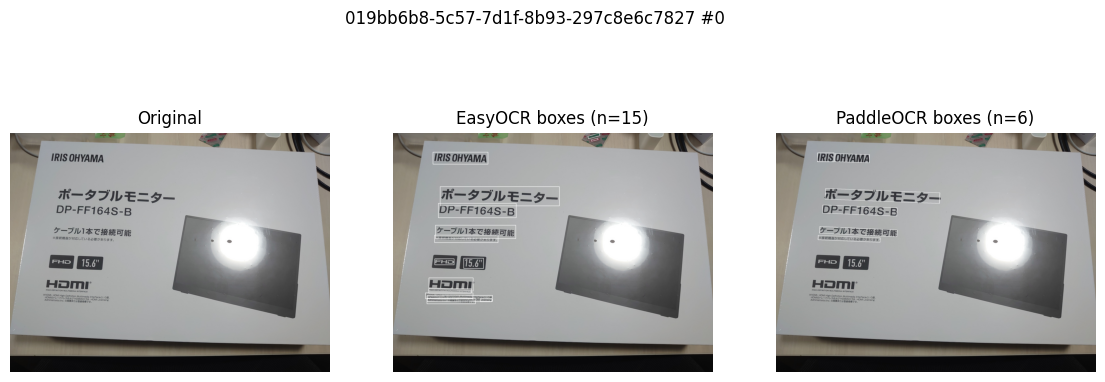

[2026/03/05 12:46:33] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:46:33] ppocr DEBUG: dt_boxes num : 34, elapsed : 0.2257072925567627
[2026/03/05 12:46:34] ppocr DEBUG: rec_res num  : 34, elapsed : 1.492788553237915


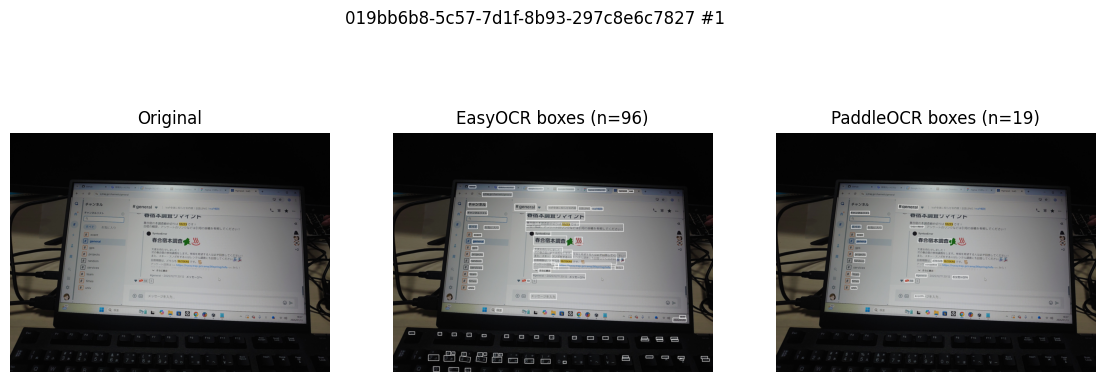

[2026/03/05 12:46:55] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:46:55] ppocr DEBUG: dt_boxes num : 9, elapsed : 0.12486696243286133
[2026/03/05 12:46:56] ppocr DEBUG: rec_res num  : 9, elapsed : 0.5931105613708496


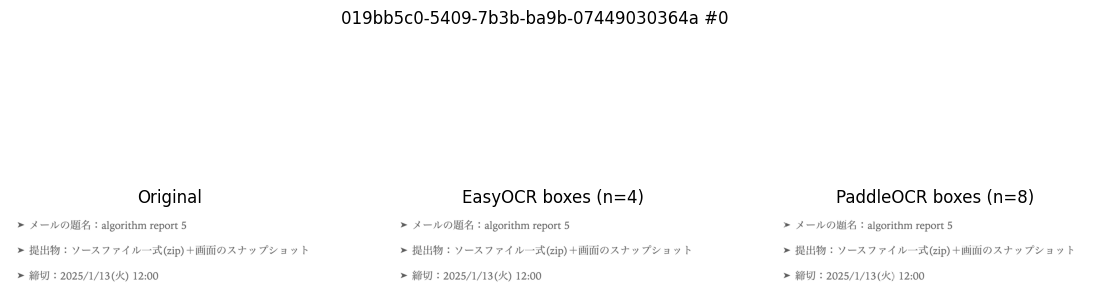

[2026/03/05 12:47:12] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:47:13] ppocr DEBUG: dt_boxes num : 8, elapsed : 0.13728761672973633
[2026/03/05 12:47:13] ppocr DEBUG: rec_res num  : 8, elapsed : 0.4286048412322998


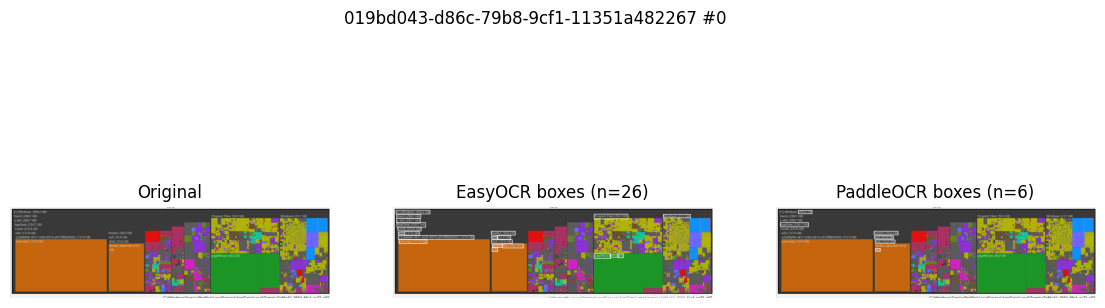

[2026/03/05 12:47:15] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:47:15] ppocr DEBUG: dt_boxes num : 7, elapsed : 0.07360029220581055
[2026/03/05 12:47:15] ppocr DEBUG: rec_res num  : 7, elapsed : 0.36243557929992676


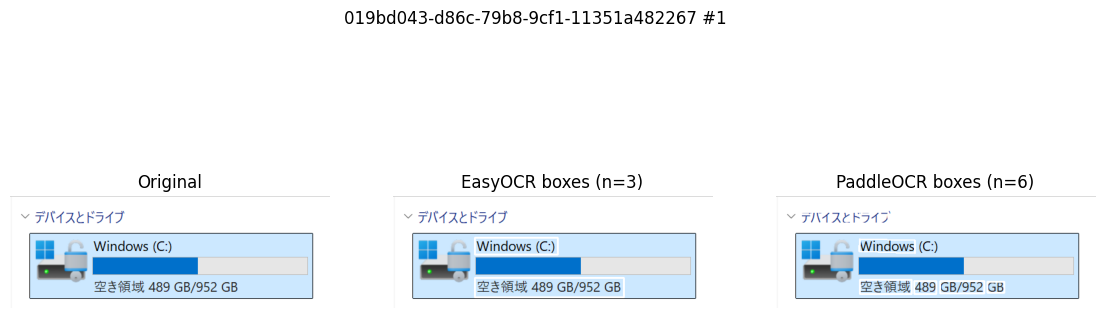

[2026/03/05 12:47:16] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:47:16] ppocr DEBUG: dt_boxes num : 2, elapsed : 0.08719706535339355
[2026/03/05 12:47:17] ppocr DEBUG: rec_res num  : 2, elapsed : 0.1946723461151123


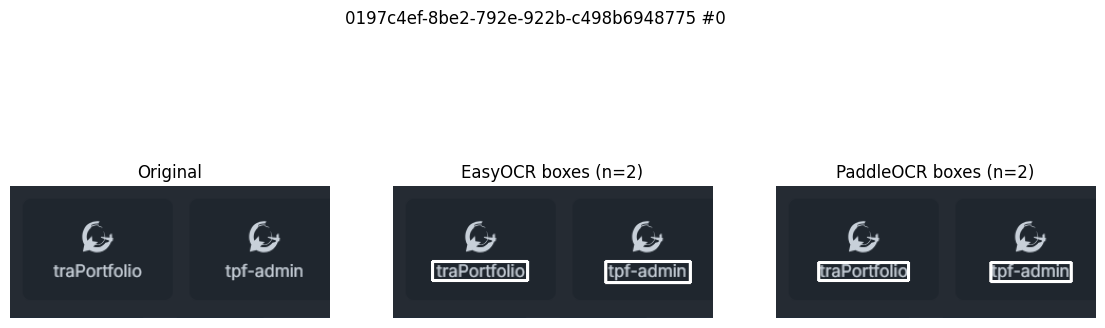

[2026/03/05 12:48:26] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:48:26] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.2506699562072754
[2026/03/05 12:48:26] ppocr DEBUG: rec_res num  : 0, elapsed : 9.5367431640625e-07


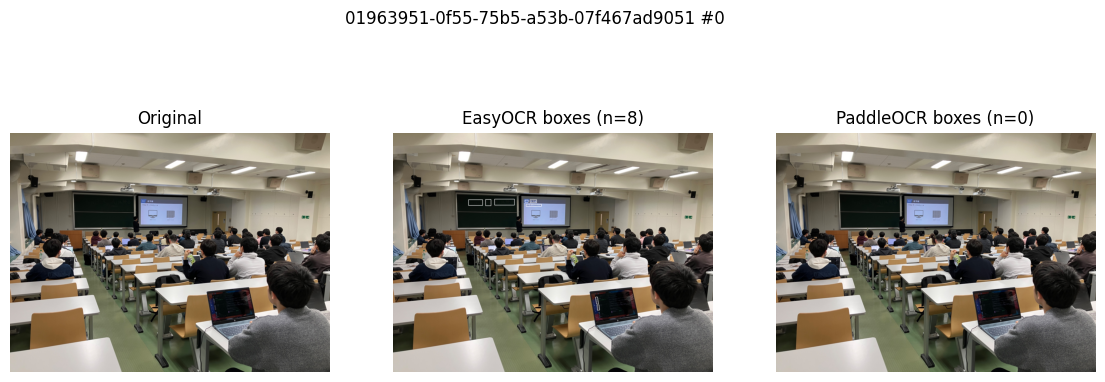

[2026/03/05 12:49:26] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:49:26] ppocr DEBUG: dt_boxes num : 8, elapsed : 0.31542181968688965
[2026/03/05 12:49:27] ppocr DEBUG: rec_res num  : 8, elapsed : 0.6992640495300293


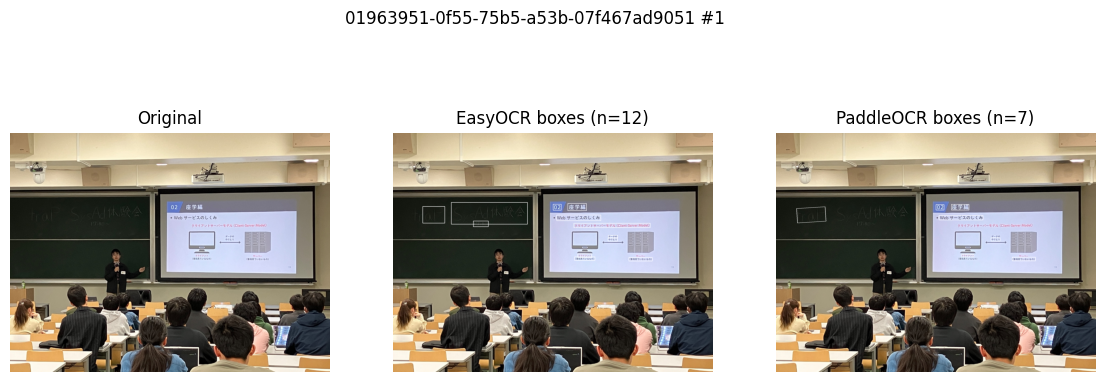

[2026/03/05 12:50:25] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:50:25] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.21700072288513184
[2026/03/05 12:50:25] ppocr DEBUG: rec_res num  : 0, elapsed : 7.152557373046875e-07


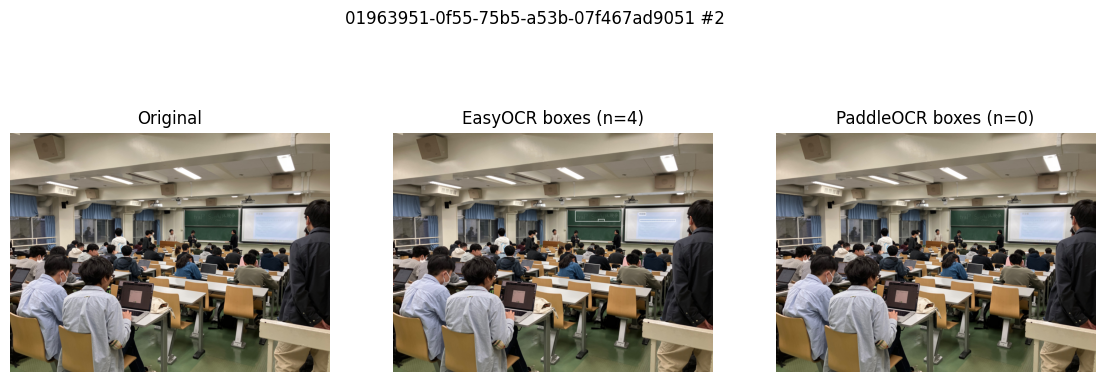

[2026/03/05 12:50:30] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:50:30] ppocr DEBUG: dt_boxes num : 13, elapsed : 0.1832418441772461
[2026/03/05 12:50:31] ppocr DEBUG: rec_res num  : 13, elapsed : 0.8742790222167969


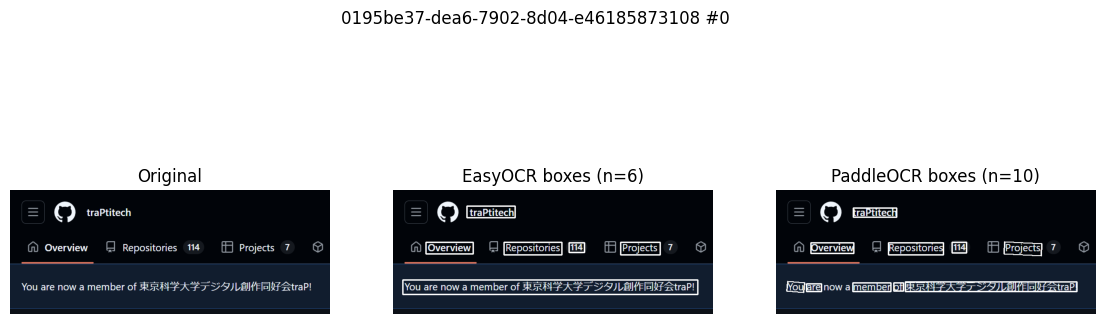

[2026/03/05 12:51:27] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:51:28] ppocr DEBUG: dt_boxes num : 34, elapsed : 0.2125864028930664
[2026/03/05 12:51:29] ppocr DEBUG: rec_res num  : 34, elapsed : 1.5955379009246826


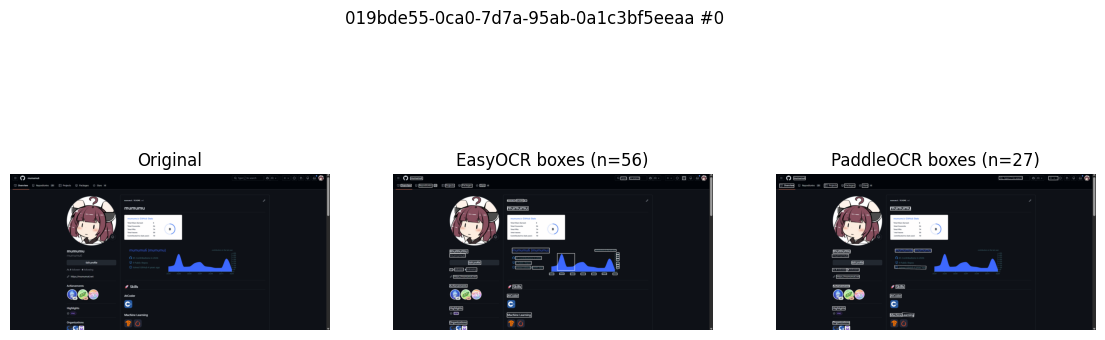

[2026/03/05 12:52:29] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:52:29] ppocr DEBUG: dt_boxes num : 59, elapsed : 0.18577933311462402
[2026/03/05 12:52:33] ppocr DEBUG: rec_res num  : 59, elapsed : 3.971120834350586


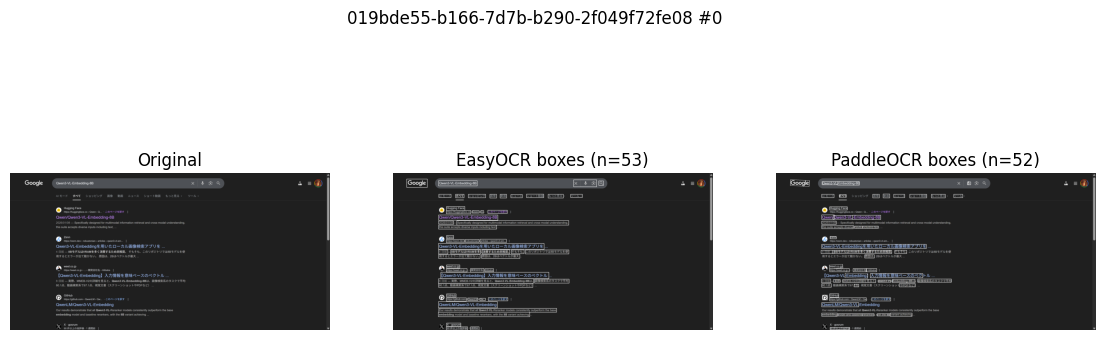

[2026/03/05 12:52:52] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:52:52] ppocr DEBUG: dt_boxes num : 8, elapsed : 0.2549159526824951
[2026/03/05 12:52:52] ppocr DEBUG: rec_res num  : 8, elapsed : 0.45368194580078125


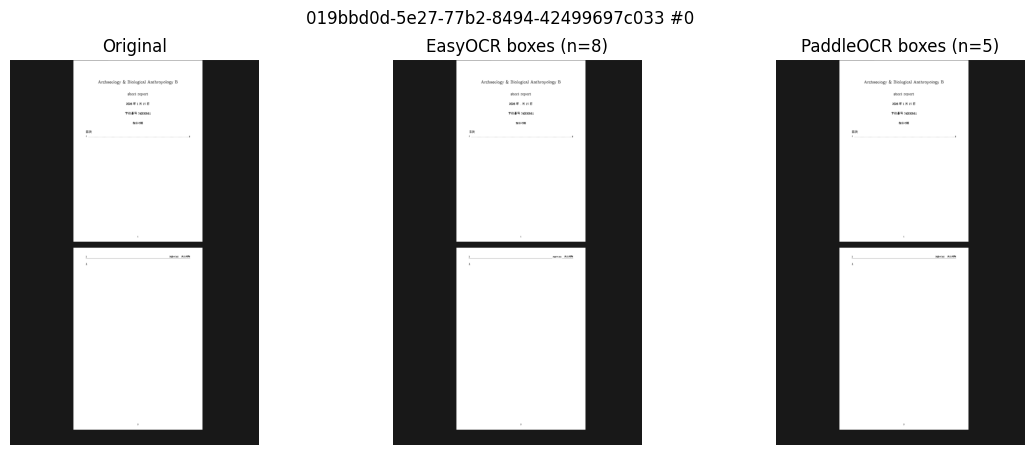

[2026/03/05 12:53:33] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:53:34] ppocr DEBUG: dt_boxes num : 8, elapsed : 0.2397768497467041
[2026/03/05 12:53:34] ppocr DEBUG: rec_res num  : 8, elapsed : 0.4885404109954834


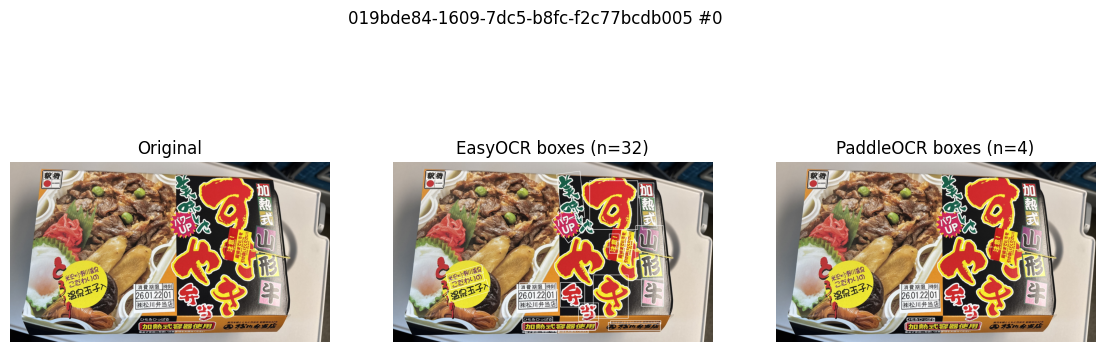

[2026/03/05 12:54:13] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:54:13] ppocr DEBUG: dt_boxes num : 3, elapsed : 0.18022871017456055
[2026/03/05 12:54:13] ppocr DEBUG: rec_res num  : 3, elapsed : 0.20128893852233887


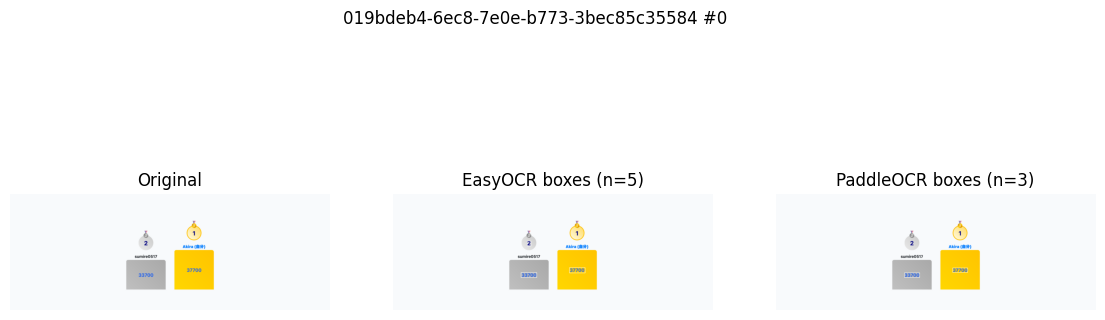

[2026/03/05 12:54:26] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:54:26] ppocr DEBUG: dt_boxes num : 26, elapsed : 0.20679211616516113
[2026/03/05 12:54:27] ppocr DEBUG: rec_res num  : 26, elapsed : 1.3182785511016846


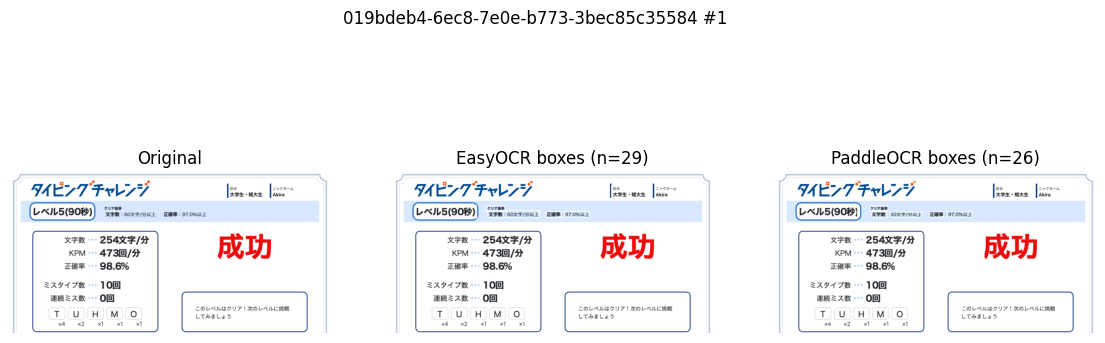

[2026/03/05 12:54:59] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:54:59] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.29068803787231445
[2026/03/05 12:54:59] ppocr DEBUG: rec_res num  : 0, elapsed : 9.5367431640625e-07


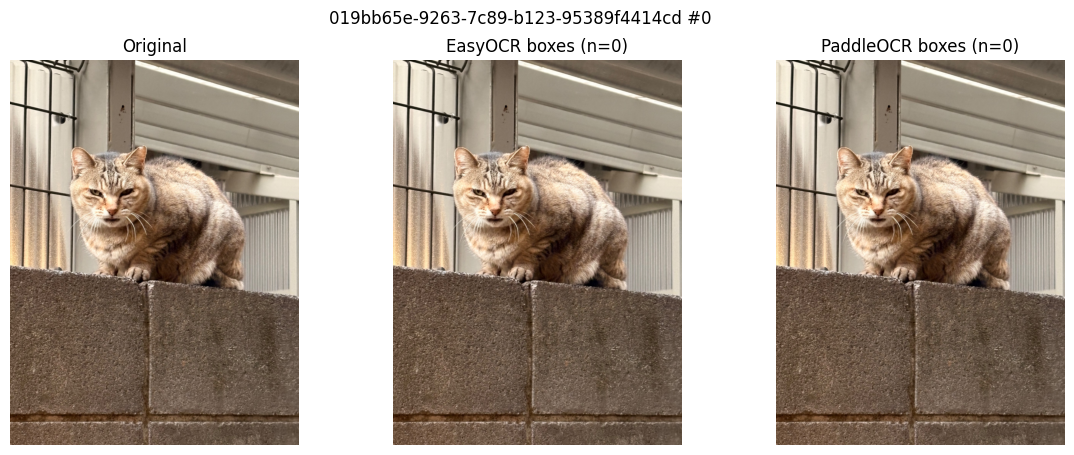

[2026/03/05 12:55:15] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/03/05 12:55:15] ppocr DEBUG: dt_boxes num : 26, elapsed : 0.20239543914794922
[2026/03/05 12:55:17] ppocr DEBUG: rec_res num  : 26, elapsed : 1.2536523342132568


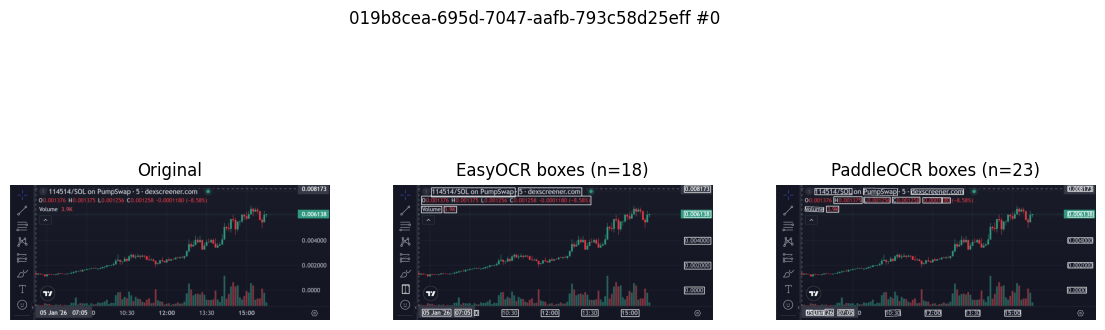

,k,messageId,image_index,easy_sec,paddle_sec,easy_n,paddle_n,easy_mean_conf,paddle_mean_conf,paddle/easy_time,easy_text_head,paddle_text_head
7,8,0197c4ef-8be2-792e-922b-c498b6948775,0,0.868347,0.288899,2,2,0.839715,0.962772,0.332700,taPorttolio tpf-admin,traPortfolio tpf-admin
6,7,019bd043-d86c-79b8-9cf1-11351a482267,1,1.400632,0.442917,3,6,0.876525,0.989885,0.316226,デバイスとドライブ Vindows (C:) 空き領域 489 GB/952 GB,デバイスとドライブ Windows 空き領域 489 GB/952 GB
11,12,0195be37-dea6-7902-8d04-e46185873108,0,3.718210,1.070069,6,10,0.903671,0.977966,0.287791,traPtitech Overview Repositories 114 Projects ...,traPtitech Qverview Repositories 114 Projects ...
0,1,019b2a64-eebc-7815-84c5-e384fabc495c,0,14.151401,3.473210,48,51,0.931651,0.990307,0.245432,予選結果 予選成績上位10チームと成績は以下の通りになります。 順位 学校名 チーム名 予選...,予選結果 予選成績上位10チームと成績は以下の通りになります. 順位 学校名 チーム名 予選...
17,18,019bdeb4-6ec8-7e0e-b773-3bec85c35584,1,11.737398,1.544374,29,26,0.620613,0.981616,0.131577,タイピンク チャレンジ 父生 短大生 Awbネ-ム クリア基準 レベル5(9の秘) 文字数 ...,タイピンクチャレンン 区分 ニックネーム 大学生 短大生 レベル5(90秒) クリア基準 文...
19,20,019b8cea-695d-7047-aafb-793c58d25eff,0,15.479702,1.480384,18,23,0.727749,0.986406,0.095634,114514/SOLon PumpSwap 5'dexscreenercom 0.00817...,PumpSwap 0.008173 114514/S0L dexscreener.com H...
13,14,019bde55-b166-7d7b-b290-2f049f72fe08,0,58.866343,4.222252,53,52,0.847294,0.968340,0.071726,Google Qwen3-VL-Embedding-8B メ| @ a Aモード すべて ...,Google Qwen3-VL. Embedding-8B し ＡＬ モード すべて 画像 ...
1,2,019a48ff-b175-783c-93fc-b4ec6731dde5,0,32.526066,2.255636,48,15,0.437904,0.887822,0.069349,SysAd 物販記録 trap SysAd Techbook looo 1 (Oひ xXS ...,物販記録 SysAd Tech book 1000 Teclbook2 SysAd Tech...
14,15,019bbd0d-5e27-77b2-8494-42499697c033,0,17.710605,0.727593,8,5,0.335852,0.963720,0.041082,Archaeology & Biologici] Anthronology B short ...,Archaeology Anthropolog? Short report 2026年1月1...
4,5,019bb5c0-5409-7b3b-ba9b-07449030364a,0,19.808392,0.747277,4,8,0.793975,0.994074,0.037725,メールの題名 algorithmreport5 提出物: ソースファイルー式(zip)十画面...,メールの題名 algorithm report 提出物 +画面のスナップショッ1 締切 20...



=== Time summary (seconds) [k>=2] ===
EasyOCR  mean=34.032  p50=32.526  p90=59.437
Paddle   mean=1.140  p50=0.838  p90=1.948

=== Avg boxes [k>=2] ===
EasyOCR  avg_n=22.4
Paddle   avg_n=11.5  (after filtering)

Saved: /content/traq_ocr_easy_vs_paddle.json


In [4]:
# %% [C] Run & compare (Easy vs Paddle) + 横並びテキスト表示
from typing import List, Dict, Any, Tuple

def pil_open_rgb(path: str) -> Image.Image:
    return Image.open(path).convert("RGB")

def poly_to_bbox(poly: List[List[float]]) -> Tuple[float,float,float,float]:
    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]
    return (min(xs), min(ys), max(xs), max(ys))

def draw_polys(img: Image.Image, items: List[Dict[str,Any]], max_polys: int = 200) -> Image.Image:
    out = img.copy()
    d = ImageDraw.Draw(out)
    for it in items[:max_polys]:
        poly = it["poly"]
        d.line(poly + [poly[0]], width=3)
    return out

def show_compare_easy_paddle(image_path: str, r_easy, r_pad, title: str = ""):
    base = pil_open_rgb(image_path)
    im_easy = draw_polys(base, r_easy["items"])
    im_pad  = draw_polys(base, r_pad["items"])

    plt.figure(figsize=(14, 5))
    for i, (im, name) in enumerate([
        (base, "Original"),
        (im_easy, f"EasyOCR boxes (n={len(r_easy['items'])})"),
        (im_pad,  f"PaddleOCR boxes (n={len(r_pad['items'])})"),
    ], start=1):
        plt.subplot(1, 3, i)
        plt.imshow(im)
        plt.title(name)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

def show_text_side_by_side(rec, r_easy, r_pad, max_chars=3000):
    easy_txt = (r_easy.get("full_text") or "")[:max_chars]
    pad_txt  = (r_pad.get("full_text")  or "")[:max_chars]

    title = f'{rec["messageId"]} #{rec["image_index"]} | Easy {r_easy["seconds"]:.3f}s / Paddle {r_pad["seconds"]:.3f}s'
    meta  = f'boxes: Easy {len(r_easy["items"])} / Paddle {len(r_pad["items"])} (after filtering)'

    display(HTML(f"""
    <div style="margin:10px 0; padding:10px; border:1px solid #ddd; border-radius:8px;">
      <div style="font-weight:700; margin-bottom:6px;">{html.escape(title)}</div>
      <div style="color:#666; margin-bottom:10px;">{html.escape(meta)}</div>
      <div style="display:flex; gap:12px;">
        <div style="flex:1;">
          <div style="font-weight:600; margin-bottom:6px;">EasyOCR</div>
          <pre style="white-space:pre-wrap; word-break:break-word; background:#fafafa; padding:10px; border-radius:6px; border:1px solid #eee; max-height:360px; overflow:auto;">{html.escape(easy_txt)}</pre>
        </div>
        <div style="flex:1;">
          <div style="font-weight:600; margin-bottom:6px;">PaddleOCR</div>
          <pre style="white-space:pre-wrap; word-break:break-word; background:#fafafa; padding:10px; border-radius:6px; border:1px solid #eee; max-height:360px; overflow:auto;">{html.escape(pad_txt)}</pre>
        </div>
      </div>
    </div>
    """))

# ---------- EasyOCR ----------
def run_easyocr(image_path: str) -> Dict[str, Any]:
    t0 = time.perf_counter()
    out = easy_reader.readtext(image_path)  # [[bbox4pts], text, conf]
    dt = time.perf_counter() - t0

    items = []
    for bbox, text, conf in out:
        poly = [[float(x), float(y)] for x, y in bbox]
        items.append({
            "text": text,
            "conf": float(conf),
            "poly": poly,
            "bbox": list(map(float, poly_to_bbox(poly))),
        })
    full_text = "\n".join([it["text"] for it in items])
    mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
    return {"engine": "easyocr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}

# ---------- PaddleOCR (v3/v2 両対応) ----------
def _to_py(x):
    return x.tolist() if hasattr(x, "tolist") else x

def _parse_paddle_v3(pred_result):
    r0 = pred_result[0] if isinstance(pred_result, (list, tuple)) and len(pred_result) > 0 else pred_result

    if hasattr(r0, "json"):
        j = r0.json
        data = j() if callable(j) else j
    elif isinstance(r0, dict):
        data = r0
    else:
        raise TypeError(f"Unexpected PaddleOCR v3 result type: {type(r0)}")

    if isinstance(data, str):
        data = json.loads(data)

    if "res" in data and isinstance(data["res"], dict):
        data = data["res"]

    texts  = data.get("rec_texts", []) or []
    scores = _to_py(data.get("rec_scores", [])) or []
    polys  = _to_py(data.get("rec_polys", None)) or _to_py(data.get("dt_polys", None))

    items = []
    if polys is None:
        return items

    for i, t in enumerate(texts):
        if i >= len(polys):
            break
        poly = polys[i]
        conf = float(scores[i]) if i < len(scores) else 0.0
        poly = [[float(x), float(y)] for x, y in poly]
        items.append({
            "text": t,
            "conf": conf,
            "poly": poly,
            "bbox": list(map(float, poly_to_bbox(poly))),
        })
    return items

# 後処理フィルタ（拾いすぎを軽く抑える）
FILTER_MIN_AREA_RATIO  = 0.00003  # 0.00003〜0.00008 くらいで調整
FILTER_SINGLE_CHAR_CONF = 0.92    # 0.92〜0.97 くらいで調整（上げるほど1文字を捨てる）

def filter_paddle_items(items, img_w, img_h,
                        min_area_ratio=FILTER_MIN_AREA_RATIO,
                        single_char_conf=FILTER_SINGLE_CHAR_CONF):
    min_area = img_w * img_h * min_area_ratio
    kept = []
    for it in items:
        x0,y0,x1,y1 = it["bbox"]
        area = max(0, x1-x0) * max(0, y1-y0)
        text = (it["text"] or "").strip()
        conf = float(it["conf"])
        if area < min_area:
            continue
        if len(text) == 1 and conf < single_char_conf:
            continue
        kept.append(it)
    return kept

# ...existing code...
def _safe_paddle_v2_lines(result):
    # Paddle v2 の返り値ゆらぎを吸収
    if result is None:
        return []
    if isinstance(result, (list, tuple)):
        if len(result) == 0:
            return []
        first = result[0]
        if first is None:
            return []
        if isinstance(first, (list, tuple)):
            return first
        return []
    return []

def run_paddle(image_path: str) -> Dict[str, Any]:
    t0 = time.perf_counter()

    # v3優先: predict
    items = None
    dt = 0.0
    if hasattr(paddle_ocr, "predict"):
        try:
            pred = paddle_ocr.predict(image_path)
            dt = time.perf_counter() - t0
            items = _parse_paddle_v3(pred)
        except Exception:
            items = None

    # v2: ocr
    if items is None:
        try:
            result = paddle_ocr.ocr(image_path, cls=True)
        except TypeError:
            result = paddle_ocr.ocr(image_path)
        dt = time.perf_counter() - t0

        lines = _safe_paddle_v2_lines(result)
        items = []
        for line in lines:
            if not line or len(line) < 2 or line[0] is None or line[1] is None:
                continue
            try:
                poly = [[float(x), float(y)] for x, y in line[0]]
                text, conf = line[1]
                items.append({
                    "text": text,
                    "conf": float(conf),
                    "poly": poly,
                    "bbox": list(map(float, poly_to_bbox(poly))),
                })
            except Exception:
                continue

    # 後処理フィルタ
    W, H = pil_open_rgb(image_path).size
    items = filter_paddle_items(items or [], W, H)

    full_text = "\n".join([it["text"] for it in items])
    mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
    return {"engine": "paddleocr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}
# ...existing code...
# ===== 実行設定 =====
MAX_IMAGES   = 20
PLOT_FIRST_N = 20   # 画像（枠）表示する枚数（0で出さない）
TEXT_FIRST_N = 20   # 横並びテキスト表示する枚数（0で出さない）

targets = records[:MAX_IMAGES]
if not targets:
    raise RuntimeError("records が空です。traQ fetch セルが成功しているか確認してください。")

# ウォームアップ（初回は重いので捨てる）
_ = run_easyocr(targets[0]["image_path"])
_ = run_paddle(targets[0]["image_path"])

rows = []
all_results = []

for k, rec in enumerate(targets, start=1):
    path = rec["image_path"]
    mid  = rec["messageId"]
    idx  = rec["image_index"]

    r_easy = run_easyocr(path)
    r_pad  = run_paddle(path)

    # 横並びテキスト（ここで出す）
    if k <= TEXT_FIRST_N:
        show_text_side_by_side(rec, r_easy, r_pad, max_chars=3000)

    # 画像（枠）比較（必要なら）
    if k <= PLOT_FIRST_N:
        show_compare_easy_paddle(path, r_easy, r_pad, title=f"{mid} #{idx}")

    rows.append({
        "k": k,
        "messageId": mid,
        "image_index": idx,
        "easy_sec": r_easy["seconds"],
        "paddle_sec": r_pad["seconds"],
        "easy_n": len(r_easy["items"]),
        "paddle_n": len(r_pad["items"]),
        "easy_mean_conf": r_easy["mean_conf"],
        "paddle_mean_conf": r_pad["mean_conf"],
        "paddle/easy_time": (r_pad["seconds"] / max(r_easy["seconds"], 1e-9)),
        "easy_text_head": (r_easy["full_text"][:120].replace("\n"," ")),
        "paddle_text_head": (r_pad["full_text"][:120].replace("\n"," ")),
    })

    all_results.append({
        "record": rec,
        "easyocr": r_easy,
        "paddleocr": r_pad,
    })

df = pd.DataFrame(rows)
display(df.sort_values("paddle/easy_time", ascending=False))

# ===== 集計（初回ウォームアップの影響を避けるなら 2枚目以降で） =====
def summarize(vals):
    vals = list(vals)
    if not vals:
        return float("nan"), float("nan"), float("nan")
    mean = float(np.mean(vals))
    p50  = float(np.percentile(vals, 50))
    p90  = float(np.percentile(vals, 90))
    return mean, p50, p90

df2 = df[df["k"] >= 2]  # 2枚目以降
easy_mean, easy_p50, easy_p90 = summarize(df2["easy_sec"].tolist())
pad_mean,  pad_p50,  pad_p90  = summarize(df2["paddle_sec"].tolist())

print("\n=== Time summary (seconds) [k>=2] ===")
print(f"EasyOCR  mean={easy_mean:.3f}  p50={easy_p50:.3f}  p90={easy_p90:.3f}")
print(f"Paddle   mean={pad_mean:.3f}  p50={pad_p50:.3f}  p90={pad_p90:.3f}")

print("\n=== Avg boxes [k>=2] ===")
print(f"EasyOCR  avg_n={df2['easy_n'].mean():.1f}")
print(f"Paddle   avg_n={df2['paddle_n'].mean():.1f}  (after filtering)")

# 保存
OUT_JSON = "/content/traq_ocr_easy_vs_paddle.json"
with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print("\nSaved:", OUT_JSON)

## gpu(L4)の場合

=== Time summary (seconds) [k>=2] ===\
EasyOCR  mean=0.736  p50=0.655  p90=1.464\
Paddle   mean=0.353  p50=0.276  p90=0.534\

=== Avg boxes [k>=2] ===\
EasyOCR  avg_n=22.4\
Paddle   avg_n=11.5  (after filtering)\
\
Saved: /content/traq_ocr_easy_vs_paddle.json